<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDS0321ENSkillsNetwork26802033-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Space X  Falcon 9 First Stage Landing Prediction**


## Hands on Lab: Complete the Machine Learning Prediction lab


Estimated time needed: **60** minutes


Space X advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is because Space X can reuse the first stage. Therefore if we can determine if the first stage will land, we can determine the cost of a launch. This information can be used if an alternate company wants to bid against space X for a rocket launch.   In this lab, you will create a machine learning pipeline  to predict if the first stage will land given the data from the preceding labs.


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Several examples of an unsuccessful landing are shown here:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


Most unsuccessful landings are planed. Space X; performs a controlled landing in the oceans.


## Objectives


Perform exploratory  Data Analysis and determine Training Labels

*   create a column for the class
*   Standardize the data
*   Split into training data and test data

\-Find best Hyperparameter for SVM, Classification Trees and Logistic Regression

*   Find the method performs best using test data


## Import Libraries and Define Auxiliary Functions


In [2]:
import piplite
await piplite.install(['numpy'])
await piplite.install(['pandas'])
await piplite.install(['seaborn'])

We will import the following libraries for the lab


In [3]:
# Pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
# NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns
# Preprocessing allows us to standarsize our data
from sklearn import preprocessing
# Allows us to split our data into training and testing data
from sklearn.model_selection import train_test_split
# Allows us to test parameters of classification algorithms and find the best one
from sklearn.model_selection import GridSearchCV
# Logistic Regression classification algorithm
from sklearn.linear_model import LogisticRegression
# Support Vector Machine classification algorithm
from sklearn.svm import SVC
# Decision Tree classification algorithm
from sklearn.tree import DecisionTreeClassifier
# K Nearest Neighbors classification algorithm
from sklearn.neighbors import KNeighborsClassifier
# To seee the classification report
from sklearn.metrics import classification_report


<ipython-input-3-5c0ba183e183>:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


This function is to plot the confusion matrix.


In [4]:
def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    ax.xaxis.set_ticklabels(['did not land', 'landed']); ax.yaxis.set_ticklabels(['did not land', 'landed']) 
    plt.show() 

## Load the dataframe


Load the data


In [5]:
from js import fetch
import io

URL1 = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
resp1 = await fetch(URL1)
text1 = io.BytesIO((await resp1.arrayBuffer()).to_py())
data = pd.read_csv(text1)

In [6]:
data.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [7]:
URL2 = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv'
resp2 = await fetch(URL2)
text2 = io.BytesIO((await resp2.arrayBuffer()).to_py())
X = pd.read_csv(text2)

Target 'Class' was already removed to leave only Independent Variable Features in text2 => X

In [8]:
X.head(100)

,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,...,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,1.0,6104.959412,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,2.0,525.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,3.0,677.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,4.0,500.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,5.0,3170.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,86.0,15400.000000,2.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
86,87.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
87,88.0,15400.000000,6.0,5.0,5.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
88,89.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


## TASK  1


Create a NumPy array from the column <code>Class</code> in <code>data</code>, by applying the method <code>to_numpy()</code>  then
assign it  to the variable <code>Y</code>,make sure the output is a  Pandas series (only one bracket df\['name of  column']).


In [9]:
Y=data['Class'].to_numpy()   
Y=pd.Series(Y, name="Class")
# Assuming Y was a Pandas Series...
print(type(Y))

<class 'pandas.core.series.Series'>


## TASK  2


Standardize the data in <code>X</code> then reassign it to the variable  <code>X</code> using the transform provided below.


In [130]:
from sklearn.preprocessing import StandardScaler
transform = preprocessing.StandardScaler()
scaler = transform.fit(X)
X = scaler.transform(X)
# X = preprocessing.StandardScaler().fit(X).transform(X)
type(X)

numpy.ndarray

We split the data into training and testing data using the  function  <code>train_test_split</code>.   The training data is divided into validation data, a second set used for training  data; then the models are trained and hyperparameters are selected using the function <code>GridSearchCV</code>.


## TASK  3


Use the function train_test_split to split the data X and Y into training and test data. Set the parameter test_size to  0.2 and random_state to 2. The training data and test data should be assigned to the following labels.


<code>X_train, X_test, Y_train, Y_test</code>


In [131]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

we can see we only have 18 test samples.


In [132]:
Y_test.shape

(18,)

## TASK  4


Create a logistic regression object  then create a  GridSearchCV object  <code>logreg_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [133]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Assuming X and Y are your features and target variable
# It is important to run this line every time to define the variables
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

# 1. Define the parameters and initialize the model object
parameters = {"C": [0.01, 0.1, 1], 'penalty': ['l2'], 'solver': ['lbfgs']}
lr = LogisticRegression()

# 2. Create and fit the GridSearchCV object
logreg_cv = GridSearchCV(lr, parameters, cv=10)
logreg_cv.fit(X_train, Y_train)

GridSearchCV(cv=10, estimator=LogisticRegression(),
             param_grid={'C': [0.01, 0.1, 1], 'penalty': ['l2'],
                         'solver': ['lbfgs']})

We output the GridSearchCV object for Logistic Regression. We display the best parameters using the data attribute best_params_ and the accuracy on the validation data using the data attribute best_score_.

In [134]:
# 3. Get the best model from the grid search
# This is the crucial step that defines the 'best_model' variable
best_model = logreg_cv.best_estimator_

# 4. Use the best model to make predictions on the test set
# This creates the y_pred variable
Y_pred = best_model.predict(X_test)

# 5. Printouts
# Now both Y_test and Y_pred are defined and ready to be used
# print(classification_report(Y_test, Y_pred))
print("tuned hpyerparameters :(best parameters) ",logreg_cv.best_params_)
print("accuracy :",logreg_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
accuracy : 0.8464285714285713


## TASK  5


Calculate the accuracy on the test data using the method <code>score</code>:


In [135]:
accuracy = logreg_cv.score(X_test, Y_test)
print("Accuracy on test data: ", accuracy)

Accuracy on test data:  0.8333333333333334


Lets look at the confusion matrix:


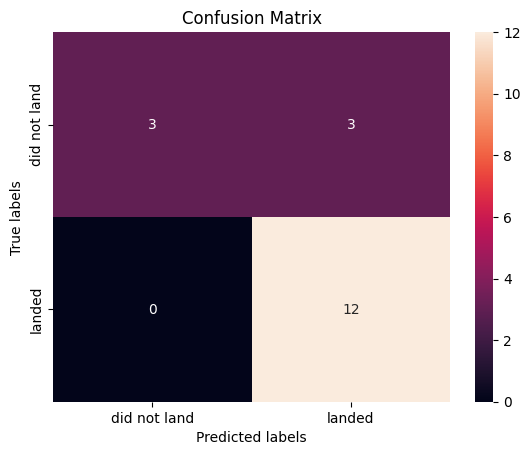

In [136]:
yhat=logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

Examining the confusion matrix, we see that Logistic Regression can distinguish between the different classes.  We see that the problem is false positives.

Overview:

True Postive - 12 (True label is "landed", Predicted label is also "landed")

False Postive - 3 (True label is "did not land", Predicted label is "landed")


## TASK  6


Create a support vector machine object then  create a  <code>GridSearchCV</code> object  <code>svm_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [137]:
parameters = {'kernel':('linear', 'rbf','poly','rbf', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma':np.logspace(-3, 3, 5)}
svm = SVC()

In [138]:
# Create the GridSearchCV object
svm_cv = GridSearchCV(svm, parameters, cv=10)

# Fit the model to the training data
svm_cv.fit(X_train, Y_train)

GridSearchCV(cv=10, estimator=SVC(),
             param_grid={'C': array([1.00000000e-03, 3.16227766e-02, 1.00000000e+00, 3.16227766e+01,
       1.00000000e+03]),
                         'gamma': array([1.00000000e-03, 3.16227766e-02, 1.00000000e+00, 3.16227766e+01,
       1.00000000e+03]),
                         'kernel': ('linear', 'rbf', 'poly', 'rbf', 'sigmoid')})

We output the GridSearchCV object for Support Vector Machine. We display the best parameters using the data attribute best_params_ and the accuracy on the validation data using the data attribute best_score_.

In [139]:
# Get the best model from the grid search
# This is the crucial step that defines the 'best_model' variable
best_model = svm_cv.best_estimator_

# Use the best model to make predictions on the test set
# This creates the y_pred variable
Y_pred = best_model.predict(X_test)

In [140]:
print("tuned hpyerparameters :(best parameters) ",svm_cv.best_params_)
print("accuracy :",svm_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'C': 1.0, 'gamma': 0.03162277660168379, 'kernel': 'sigmoid'}
accuracy : 0.8482142857142856


## TASK  7


Calculate the accuracy on the test data using the method <code>score</code>:


In [141]:
accuracy = svm_cv.score(X_test, Y_test)
print("Accuracy on test data: ", accuracy)

Accuracy on test data:  0.8333333333333334


We can plot the confusion matrix


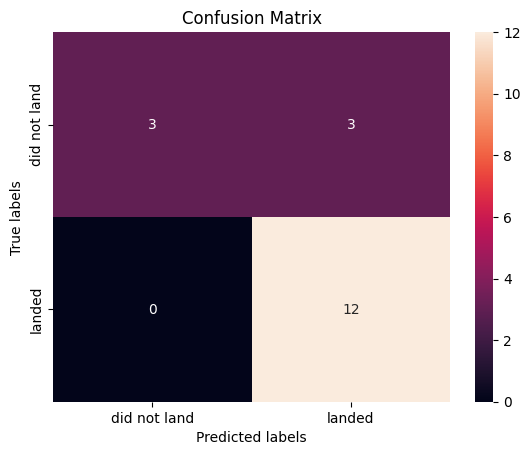

In [142]:
yhat=svm_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

Examining the confusion matrix, we see that the Support Vector Machine can distinguish between the different classes.  We see that the problem is false positives.

Overview:

True Postive - 12 (True label is "landed", Predicted label is also "landed")

False Postive - 3 (True label is "did not land", Predicted label is "landed")


## TASK  8


Create a decision tree classifier object then  create a  <code>GridSearchCV</code> object  <code>tree_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [143]:
parameters = {'criterion': ['gini', 'entropy'],
     'splitter': ['best', 'random'],
     'max_depth': [2*n for n in range(1,10)],
     'max_features': ['log2', 'sqrt'],
     'min_samples_leaf': [1, 2, 4],
     'min_samples_split': [2, 5, 10]}

tree = DecisionTreeClassifier()

In [144]:
# Create the GridSearchCV object
tree_cv = GridSearchCV(tree, parameters, cv=10)

# Fit the model to the training data
tree_cv.fit(X_train, Y_train)


GridSearchCV(cv=10, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 4, 6, 8, 10, 12, 14, 16, 18],
                         'max_features': ['log2', 'sqrt'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'splitter': ['best', 'random']})

We output the GridSearchCV object for Decision Tree. We display the best parameters using the data attribute best_params_ and the accuracy on the validation data using the data attribute best_score_.

In [145]:
print("tuned hpyerparameters :(best parameters) ",tree_cv.best_params_)
print("accuracy :",tree_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'criterion': 'entropy', 'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'splitter': 'best'}
accuracy : 0.8892857142857145


## TASK  9


Calculate the accuracy of tree_cv on the test data using the method <code>score</code>:


In [146]:
accuracy = tree_cv.score(X_test, Y_test)
print("Accuracy on test data: ", accuracy)

Accuracy on test data:  0.8333333333333334


We can plot the confusion matrix


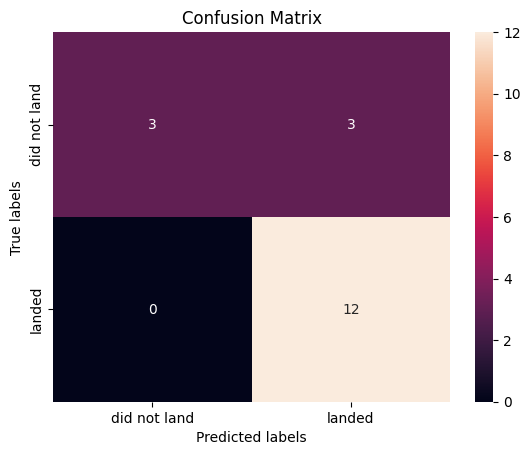

In [147]:
yhat = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

Examining the confusion matrix, we see that the Decision Tree can distinguish between the different classes.  We see that the problem is false positives.

Overview:

True Postive - 12 (True label is "landed", Predicted label is also "landed")

False Postive - 3 (True label is "did not land", Predicted label is "landed")


## TASK  10


Create a k nearest neighbors object then  create a  <code>GridSearchCV</code> object  <code>knn_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [148]:
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1,2]}

KNN = KNeighborsClassifier()

In [149]:
# Create the GridSearchCV object
knn_cv = GridSearchCV(KNN, parameters, cv=10)

# Fit the model to your training data
knn_cv.fit(X_train, Y_train)

GridSearchCV(cv=10, estimator=KNeighborsClassifier(),
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                         'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'p': [1, 2]})

We output the GridSearchCV object for K-Nearest Neighbours. We display the best parameters using the data attribute best_params_ and the accuracy on the validation data using the data attribute best_score_.

In [150]:
print("tuned hpyerparameters :(best parameters) ",knn_cv.best_params_)
print("accuracy :",knn_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'algorithm': 'auto', 'n_neighbors': 10, 'p': 1}
accuracy : 0.8482142857142858


## TASK  11


Calculate the accuracy of knn_cv on the test data using the method <code>score</code>:


In [151]:
accuracy = knn_cv.score(X_test, Y_test)
print("Accuracy on test data: ", accuracy)

Accuracy on test data:  0.8333333333333334


We can plot the confusion matrix


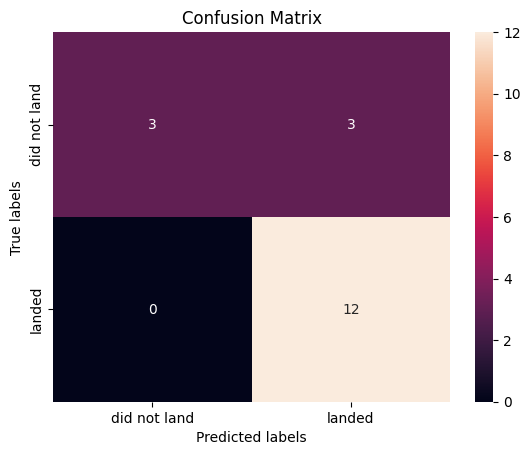

In [152]:
yhat = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

Examining the confusion matrix, we see that K-Nearest Neighbours can distinguish between the different classes.  We see that the problem is false positives.

Overview:

True Postive - 12 (True label is "landed", Predicted label is also "landed")

False Postive - 3 (True label is "did not land", Predicted label is "landed")


## TASK  12


Find the method performs best:


```text
All results are practically the same as far as the test data Accuracy Score of 0.8333333333333334 is concerned, and this convergence is not unusual given the small dataset. In this scenario, where the single test set score is identical for all models, the CV scores can provide the nuanced information needed to differentiate them. The CV score is the best indicator of which model generalizes better to unseen data, based on the entire training set, before the final, single test set evaluation. Therefore, you might now select the Decision Tree model as the best candidates (though maybe a Random Forest would be more robust). If splitting hairs then there is still very little difference in performance as these numbers are also not that far apart:

Decision Tree    0.8767857142857143
KNN              0.8482142857142858
SVM              0.8482142857142856
LogRegression    0.8464285714285713

In further research I have found optimizing a Random Forest could indeed be a way forwards, though it is harder to interpret. I will add this suggestion to the Presentation and link to a separate GitHub findings notebook.
```

In [157]:
import numpy as np

# Ensure all data is converted to NumPy arrays
X_train = np.array(X_train)
X_test = np.array(X_test)

# Print the comparison table
print("\t\tCross Validation Accuracy\tTest Data Accuracy")

print("Tree\t\t{}\t\t\t\t{}".format(round(tree_cv.best_score_, 5), round(tree_cv.score(X_test, Y_test), 5)))
print("SVM\t\t{}\t\t\t\t{}".format(round(svm_cv.best_score_, 5), round(svm_cv.score(X_test, Y_test), 5)))
print("KNN\t\t{}\t\t\t\t{}".format(round(knn_cv.best_score_, 5), round(knn_cv.score(X_test, Y_test), 5)))
print("LogReg\t\t{}\t\t\t\t{}".format(round(logreg_cv.best_score_, 5), round(logreg_cv.score(X_test, Y_test), 5)))

# Create a dictionary for comparison
comparison = {}

comparison['Tree'] = {'CV Accuracy': round(tree_cv.best_score_, 5), 'Test Data Accuracy': round(tree_cv.score(X_test, Y_test), 5)}
comparison['SVM'] = {'CV Accuracy': round(svm_cv.best_score_, 5), 'Test Data Accuracy': round(svm_cv.score(X_test, Y_test), 5)}
comparison['KNN'] = {'CV Accuracy': round(knn_cv.best_score_, 5), 'Test Data Accuracy': round(knn_cv.score(X_test, Y_test), 5)}
comparison['LogReg'] = {'CV Accuracy': round(logreg_cv.best_score_, 5), 'Test Data Accuracy': round(logreg_cv.score(X_test, Y_test), 5)}

# Print the comparison dictionary
print("\nComparison Dictionary:")
for model, metrics in comparison.items():
    print(f"{model}: {metrics}")

		Cross Validation Accuracy	Test Data Accuracy
Tree		0.88929				0.83333
SVM		0.84821				0.83333
KNN		0.84821				0.83333
LogReg		0.84643				0.83333

Comparison Dictionary:
Tree: {'CV Accuracy': 0.88929, 'Test Data Accuracy': 0.83333}
SVM: {'CV Accuracy': 0.84821, 'Test Data Accuracy': 0.83333}
KNN: {'CV Accuracy': 0.84821, 'Test Data Accuracy': 0.83333}
LogReg: {'CV Accuracy': 0.84643, 'Test Data Accuracy': 0.83333}


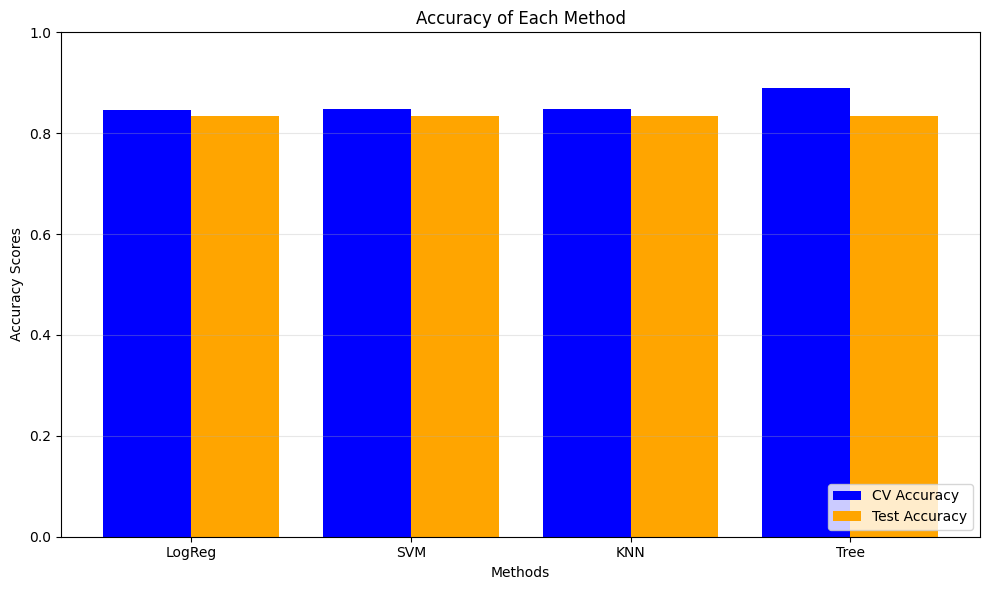

In [11]:
# comparison dictionary (from earlier)
comparison = {
    'LogReg': {'CV Accuracy': 0.84643, 'Test Data Accuracy': 0.83333},
    'SVM': {'CV Accuracy': 0.84821, 'Test Data Accuracy': 0.83333},
    'KNN': {'CV Accuracy': 0.84821, 'Test Data Accuracy': 0.83333},
    'Tree': {'CV Accuracy': 0.88929, 'Test Data Accuracy': 0.83333}
}

# Extract data
x = list(comparison.keys())  # ['LogReg', 'SVM', 'KNN', 'Tree']
y1 = [comparison[meth]['CV Accuracy'] for meth in x]  # CV Accuracy
y2 = [comparison[meth]['Test Data Accuracy'] for meth in x]  # Test Accuracy

# Create x-axis positions
x_axis = np.arange(len(x))

# Plot bars
plt.figure(figsize=(10, 6))
plt.bar(x_axis - 0.2, y1, 0.4, label='CV Accuracy', color='blue')
plt.bar(x_axis + 0.2, y2, 0.4, label='Test Accuracy', color='orange')

# Customize the plot
plt.ylim([0, 1])
plt.xticks(x_axis, x)  # Label x-axis with method names
plt.xlabel("Methods")
plt.ylabel("Accuracy Scores")
plt.title("Accuracy of Each Method")
plt.legend(loc='lower right')

# Add grid for better readability
plt.grid(axis='y', alpha=0.3)

# Show the plot
plt.tight_layout()
plt.show()

<!--## Change Log--!>



Authors

Joseph Santarcangelo has a PhD in Electrical Engineering, his research focused on using machine learning, signal processing, and computer vision to determine how videos impact human cognition. Joseph has been working for IBM since he completed his PhD.


<!--| Date (YYYY-MM-DD) | Version | Changed By      | Change Description      |
| ----------------- | ------- | -------------   | ----------------------- |
| 2022-11-09        | 1.0     | Pratiksha Verma | Converted initial version to Jupyterlite|--!>


### <h3 align="center"> IBM Corporation 2022. All rights reserved. <h3/>
